In [1]:
import os
print(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))

/home/daniil_gorenkov/wheel_defects


In [2]:
from src.mixins.preprocessor import PreprocessorMixin
from src.mixins.plot_utils import TargetSpaceVisualizer
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import config

prep = PreprocessorMixin()
vis = TargetSpaceVisualizer()

In [3]:
samples = prep.load_samples("prep_data")
samples[0]

{'X': array([-0.5,  0.7,  0.5,  0.5,  0.6, -1.1,  0.8,  1. , -0.5,  0.7, -1.4,
        -2.4,  1.3, -1. ,  0.8, -0.9,  0.7, -0.6,  0.5,  0.6,  1. , -1. ,
         0.7, -0.5, -0.5,  0.9,  0.8,  0.5, -0.9, -0.5, -0.6,  0.6,  0.5,
         0.7,  0.5, -1.1,  0.5,  0.5]),
 'speed': array([11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28]),
 'target': 1}

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Data in space'}, xlabel='Component 1', ylabel='Component 2'>)

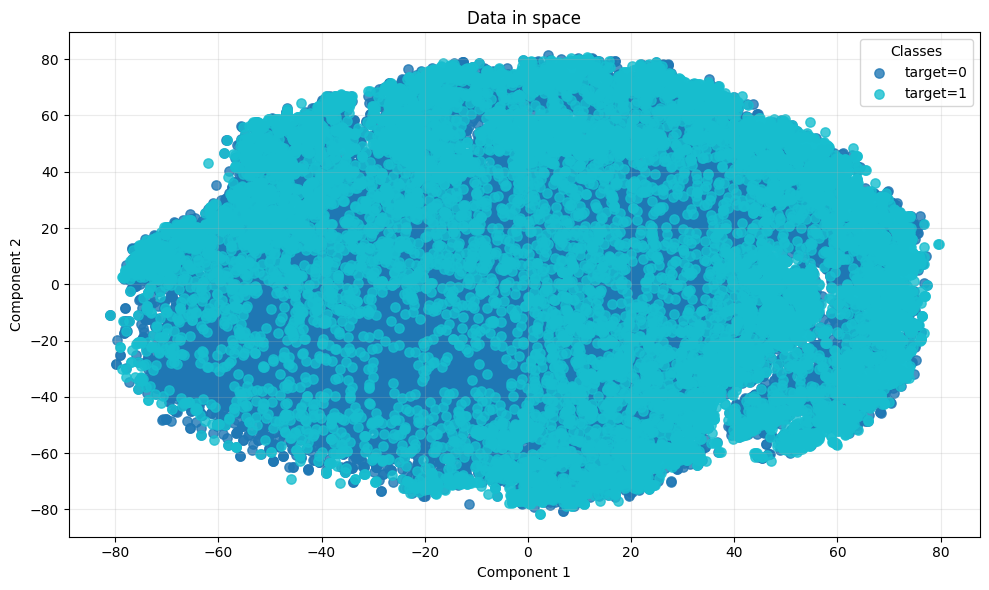

In [4]:
vis.plot(samples,"Data in space")

In [3]:
res = prep.preprocess()
res[0]

Found rotation boundaries: 4017
Found rotation boundaries: 4009
Found rotation boundaries: 4020
Found rotation boundaries: 4032
Found rotation boundaries: 8326
Found rotation boundaries: 4841
Found rotation boundaries: 0
Found rotation boundaries: 8481
Found rotation boundaries: 8440
Class distribution in samples: Counter({0: 32890, 1: 12285})


{'X': array([-0.5,  0.7,  0.5,  0.5,  0.6, -1.1,  0.8,  1. , -0.5,  0.7, -1.4,
        -2.4,  1.3, -1. ,  0.8, -0.9,  0.7, -0.6,  0.5,  0.6,  1. , -1. ,
         0.7, -0.5, -0.5,  0.9,  0.8,  0.5, -0.9, -0.5, -0.6,  0.6,  0.5,
         0.7,  0.5, -1.1,  0.5,  0.5]),
 'speed': array([11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28]),
 'target': 1}

In [7]:
import torch

signal = torch.tensor(res[0]["X"],dtype=torch.float32)
speed = torch.tensor(res[0]["speed"],dtype=torch.float32)

In [29]:
speed.unsqueeze(0).unsqueeze(0).shape

torch.Size([1, 1, 38])

In [30]:
out_ch = 2
kernel = 3

conv = torch.nn.Conv1d(1, out_ch, kernel, padding=kernel//2)
x = conv(speed.unsqueeze(0).unsqueeze(0)) # [B, C, L]
print(x.size())
print(x)

torch.Size([1, 2, 38])
tensor([[[-5.7738, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892,
          -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892,
          -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892,
          -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892,
          -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892, -4.7892,
          -4.7892, -4.7892, -0.5008],
         [ 4.1173, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237,
          -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237,
          -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237,
          -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237,
          -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237, -2.0237,
          -2.0237, -2.0237, -6.6686]]], grad_fn=<ConvolutionBackward0>)


In [31]:
norm = torch.nn.BatchNorm1d(out_ch)
x = norm(x)
print(x.size())
print(x)

torch.Size([1, 2, 38])
tensor([[[-1.5125, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227,
          -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227,
          -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227,
          -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227,
          -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227, -0.1227,
          -0.1227, -0.1227,  5.9304],
         [ 4.8874, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315,
          -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315,
          -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315,
          -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315,
          -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315, -0.0315,
          -0.0315, -0.0315, -3.7520]]], grad_fn=<NativeBatchNormBackward0>)


In [32]:
act = torch.nn.GELU()
x = act(x)
print(x.size())
print(x)

torch.Size([1, 2, 38])
tensor([[[-9.8619e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02, -5.5366e-02,
          -5.5366e-02, -5.5366e-02,  5.9304e+00],
         [ 4.8874e+00, -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02,
          -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02,
          -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02,
          -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02,
          -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02, -1.5372e-02,
          -1.5372e-02, -1.5

In [33]:
dropout = torch.nn.Dropout(0.2)
x = dropout(x)
print(x.size())
print(x)

torch.Size([1, 2, 38])
tensor([[[-0.1233, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692,
          -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0000,
          -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692,
          -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692, -0.0692,
          -0.0000, -0.0000, -0.0692, -0.0692, -0.0692, -0.0692, -0.0000,
          -0.0692, -0.0692,  7.4130],
         [ 6.1092, -0.0000, -0.0000, -0.0192, -0.0192, -0.0192, -0.0192,
          -0.0192, -0.0192, -0.0192, -0.0192, -0.0000, -0.0192, -0.0192,
          -0.0192, -0.0000, -0.0192, -0.0000, -0.0192, -0.0192, -0.0192,
          -0.0192, -0.0192, -0.0192, -0.0192, -0.0192, -0.0192, -0.0192,
          -0.0192, -0.0192, -0.0000, -0.0192, -0.0192, -0.0192, -0.0192,
          -0.0192, -0.0192, -0.0000]]], grad_fn=<MulBackward0>)


In [34]:
pool = torch.nn.AdaptiveAvgPool1d(1)
x = pool(x)
print(x.size())
print(x)

torch.Size([1, 2, 1])
tensor([[[0.1336],
         [0.1456]]], grad_fn=<SqueezeBackward1>)


In [35]:
x = x.squeeze(-1)
print(x.size())
print(x)

torch.Size([1, 2])
tensor([[0.1336, 0.1456]], grad_fn=<SqueezeBackward1>)
